# Sprint 1 – CRS Mismatch Identification and Resolution

**Project:** Urban Streetscape Intervention Analysis (USIA)  
**Team:** Team B — Traffic Volumes & Parking  
**Prepared by:** Pahalavan Kandeepan  
**Buddy:** Obulareddy  
**Sprint:** Sprint 1  

---

### Objective

Before the team can do any buffer analysis or spatial joins between datasets, all spatial data needs to be in the same Coordinate Reference System (CRS). This notebook checks the CRS of every spatial dataset the team is using, documents the mismatches, and reprojects everything to a common CRS so they can be used together accurately.

### Why this matters

If two datasets are in different CRS and you try to overlay or join them, the geometries won't line up properly. A street in one dataset might appear kilometres away from where it should be in another. For our buffer analysis (parking zones around bike lanes), this would give completely wrong results.

## 1. Setup

In [12]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## 2. Load All Spatial Datasets and Check CRS

In [13]:
# Load all spatial datasets
streets = gpd.read_file('streets_spatial.gpkg')
study_area = gpd.read_file('street_spatial_study_area.gpkg')
road_segments = gpd.read_file('road_segments_15dec.shp')
popup = gpd.read_file('popup_bike_lanes.geojson')

# Check CRS of each
datasets = {
    'streets_spatial.gpkg': streets,
    'street_spatial_study_area.gpkg': study_area,
    'road_segments_15dec.shp': road_segments,
    'popup_bike_lanes.geojson': popup
}

print('=== CRS CHECK FOR ALL SPATIAL DATASETS ===')
print()
for name, gdf in datasets.items():
    epsg = gdf.crs.to_epsg() if gdf.crs else 'None'
    crs_name = gdf.crs.name if gdf.crs else 'Unknown'
    print(f'{name}')
    print(f'  EPSG: {epsg}')
    print(f'  CRS Name: {crs_name}')
    print(f'  Rows: {len(gdf)}')
    print()

=== CRS CHECK FOR ALL SPATIAL DATASETS ===

streets_spatial.gpkg
  EPSG: 7899
  CRS Name: GDA2020 / Vicgrid
  Rows: 315

street_spatial_study_area.gpkg
  EPSG: 7899
  CRS Name: GDA2020 / Vicgrid
  Rows: 316

road_segments_15dec.shp
  EPSG: 7855
  CRS Name: GDA2020 / MGA zone 55
  Rows: 12035

popup_bike_lanes.geojson
  EPSG: 4326
  CRS Name: WGS 84
  Rows: 354



## 3. CRS Mismatch Summary

In [14]:
summary_data = []
for name, gdf in datasets.items():
    epsg = gdf.crs.to_epsg() if gdf.crs else 'None'
    crs_name = gdf.crs.name if gdf.crs else 'Unknown'
    geom_type = gdf.geometry.geom_type.unique().tolist()
    summary_data.append({
        'Dataset': name,
        'EPSG Code': epsg,
        'CRS Name': crs_name,
        'Geometry Type': str(geom_type),
        'Row Count': len(gdf)
    })

summary_df = pd.DataFrame(summary_data)
print('CRS Summary Table:')
display(summary_df)

# check for mismatches
unique_crs = summary_df['EPSG Code'].unique()
print(f'\nTotal unique CRS found: {len(unique_crs)}')
print(f'CRS codes: {unique_crs.tolist()}')

if len(unique_crs) > 1:
    print('\nMISMATCH DETECTED — datasets are NOT in the same CRS')
    print('These need to be reprojected before any spatial joins or buffer analysis')
else:
    print('\nAll datasets are in the same CRS — no reprojection needed')

CRS Summary Table:


,Dataset,EPSG Code,CRS Name,Geometry Type,Row Count
0,streets_spatial.gpkg,7899,GDA2020 / Vicgrid,['LineString'],315
1,street_spatial_study_area.gpkg,7899,GDA2020 / Vicgrid,"['MultiPolygon', 'Polygon']",316
2,road_segments_15dec.shp,7855,GDA2020 / MGA zone 55,['LineString'],12035
3,popup_bike_lanes.geojson,4326,WGS 84,['MultiLineString'],354



Total unique CRS found: 3
CRS codes: [7899, 7855, 4326]

MISMATCH DETECTED — datasets are NOT in the same CRS
These need to be reprojected before any spatial joins or buffer analysis


## 4. Understanding the CRS Differences

We have 3 different CRS across our 4 spatial datasets:

- **EPSG:7899 (GDA2020 / Vicgrid)** — used by streets_spatial and street_spatial_study_area. This is a Victorian state projection optimised for accuracy across Victoria. Uses metres as units.

- **EPSG:7855 (GDA2020 / MGA zone 55)** — used by road_segments. This is a UTM zone projection commonly used in Victoria for detailed mapping. Also uses metres.

- **EPSG:4326 (WGS84)** — used by popup_bike_lanes. This is the standard global latitude/longitude system used by Google Maps and most web mapping. Uses degrees, not metres.

The key issue is that EPSG:4326 uses degrees while the other two use metres. If we try to do buffer analysis (e.g. 20m buffer around a bike lane) on EPSG:4326 data, the buffer would be in degrees which gives wrong results. We need everything in a metre-based projection.

## 5. Choosing a Common CRS

Since the IV-provided datasets (streets_spatial and study_area) use **EPSG:7899**, and the PO metadata document recommends using EPSG:7899, 7855, or 7844, we will standardise everything to **EPSG:7899 (GDA2020 / Vicgrid)** as the common CRS.

This makes sense because:
- It's what IV used for their own data
- It covers all of Victoria (not just one UTM zone)
- It uses metres which is needed for buffer analysis

## 6. Reprojecting Mismatched Datasets

In [15]:
TARGET_CRS = 'EPSG:7899'

# streets_spatial already in 7899 — no change needed
print('streets_spatial.gpkg: already in EPSG:7899 — no reprojection needed')

# study_area already in 7899 — no change needed
print('street_spatial_study_area.gpkg: already in EPSG:7899 — no reprojection needed')

# road_segments needs reprojection from 7855 to 7899
road_segments_reproj = road_segments.to_crs(TARGET_CRS)
print(f'road_segments_15dec.shp: reprojected from EPSG:7855 to EPSG:{road_segments_reproj.crs.to_epsg()}')

# popup needs reprojection from 4326 to 7899
popup_reproj = popup.to_crs(TARGET_CRS)
print(f'popup_bike_lanes.geojson: reprojected from EPSG:4326 to EPSG:{popup_reproj.crs.to_epsg()}')

streets_spatial.gpkg: already in EPSG:7899 — no reprojection needed
street_spatial_study_area.gpkg: already in EPSG:7899 — no reprojection needed
road_segments_15dec.shp: reprojected from EPSG:7855 to EPSG:7899
popup_bike_lanes.geojson: reprojected from EPSG:4326 to EPSG:7899


## 7. Verify Reprojection — Before and After Comparison

In [16]:
# show the coordinate ranges before and after reprojection
print('=== POPUP BIKE LANES — BEFORE REPROJECTION (EPSG:4326) ===')
print(f'X range: {popup.total_bounds[0]:.4f} to {popup.total_bounds[2]:.4f} (degrees)')
print(f'Y range: {popup.total_bounds[1]:.4f} to {popup.total_bounds[3]:.4f} (degrees)')
print()
print('=== POPUP BIKE LANES — AFTER REPROJECTION (EPSG:7899) ===')
print(f'X range: {popup_reproj.total_bounds[0]:.2f} to {popup_reproj.total_bounds[2]:.2f} (metres)')
print(f'Y range: {popup_reproj.total_bounds[1]:.2f} to {popup_reproj.total_bounds[3]:.2f} (metres)')
print()

print('=== ROAD SEGMENTS — BEFORE REPROJECTION (EPSG:7855) ===')
print(f'X range: {road_segments.total_bounds[0]:.2f} to {road_segments.total_bounds[2]:.2f}')
print(f'Y range: {road_segments.total_bounds[1]:.2f} to {road_segments.total_bounds[3]:.2f}')
print()
print('=== ROAD SEGMENTS — AFTER REPROJECTION (EPSG:7899) ===')
print(f'X range: {road_segments_reproj.total_bounds[0]:.2f} to {road_segments_reproj.total_bounds[2]:.2f}')
print(f'Y range: {road_segments_reproj.total_bounds[1]:.2f} to {road_segments_reproj.total_bounds[3]:.2f}')
print()

# compare with streets_spatial which is already in 7899
print('=== STREETS SPATIAL — REFERENCE (EPSG:7899) ===')
print(f'X range: {streets.total_bounds[0]:.2f} to {streets.total_bounds[2]:.2f}')
print(f'Y range: {streets.total_bounds[1]:.2f} to {streets.total_bounds[3]:.2f}')
print()

# check if ranges now overlap
print('If the coordinate ranges are now in the same ballpark, reprojection was successful.')

=== POPUP BIKE LANES — BEFORE REPROJECTION (EPSG:4326) ===
X range: 144.8859 to 145.0315 (degrees)
Y range: -37.8871 to -37.7527 (degrees)

=== POPUP BIKE LANES — AFTER REPROJECTION (EPSG:7899) ===
X range: 2489955.91 to 2502776.39 (metres)
Y range: 2401551.20 to 2416463.87 (metres)

=== ROAD SEGMENTS — BEFORE REPROJECTION (EPSG:7855) ===
X range: 46109.63 to 493840.07
Y range: 5739341.55 to 6208541.32

=== ROAD SEGMENTS — AFTER REPROJECTION (EPSG:7899) ===
X range: 2230292.34 to 2673808.06
Y range: 2335395.61 to 2810321.81

=== STREETS SPATIAL — REFERENCE (EPSG:7899) ===
X range: 2238009.44 to 2670067.60
Y range: 2335395.61 to 2808686.38

If the coordinate ranges are now in the same ballpark, reprojection was successful.


## 8. Visual Verification — Overlay All Datasets on One Map

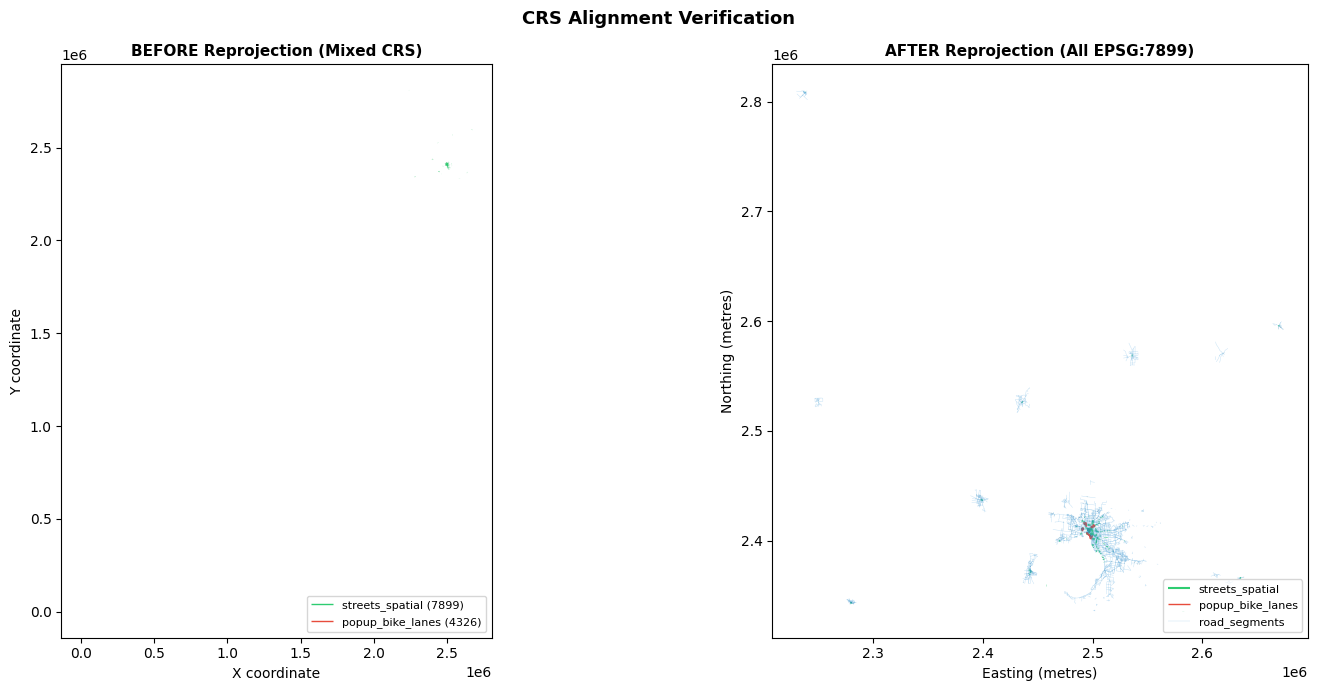

Map saved as crs_alignment_check.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# BEFORE — plotting in original CRS (will look misaligned)
axes[0].set_title('BEFORE Reprojection (Mixed CRS)', fontweight='bold', fontsize=11)
streets.plot(ax=axes[0], color='#2ecc71', linewidth=1, label='streets_spatial (7899)')
popup.plot(ax=axes[0], color='#e74c3c', linewidth=1, label='popup_bike_lanes (4326)')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')

# AFTER — plotting after reprojection (should align)
axes[1].set_title('AFTER Reprojection (All EPSG:7899)', fontweight='bold', fontsize=11)
streets.plot(ax=axes[1], color='#2ecc71', linewidth=1.5, label='streets_spatial')
popup_reproj.plot(ax=axes[1], color='#e74c3c', linewidth=1, label='popup_bike_lanes')
road_segments_reproj.plot(ax=axes[1], color='#3498db', linewidth=0.3, alpha=0.3, label='road_segments')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_xlabel('Easting (metres)')
axes[1].set_ylabel('Northing (metres)')

plt.suptitle('CRS Alignment Verification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('crs_alignment_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Map saved as crs_alignment_check.png')

## 9. Export Reprojected Datasets

In [18]:
# save the reprojected files so the team can use them directly
popup_reproj.to_file('popup_bike_lanes_EPSG7899.geojson', driver='GeoJSON')
print('Saved: popup_bike_lanes_EPSG7899.geojson')

# drop fid column to avoid conflict then save road segments
road_segments_reproj = road_segments_reproj.drop(columns=['fid'], errors='ignore')
road_segments_reproj.to_file('road_segments_15dec_EPSG7899.geojson', driver='GeoJSON')
print('Saved: road_segments_15dec_EPSG7899.geojson')

print()
print('These files are ready to use for spatial joins and buffer analysis.')
print('No further CRS conversion needed — everything is now in EPSG:7899.')

Saved: popup_bike_lanes_EPSG7899.geojson
Saved: road_segments_15dec_EPSG7899.geojson

These files are ready to use for spatial joins and buffer analysis.
No further CRS conversion needed — everything is now in EPSG:7899.


## 10. Final CRS Status Table

In [19]:
final_data = [
    {'Dataset': 'streets_spatial.gpkg', 'Original CRS': 'EPSG:7899', 'Action': 'No change needed', 'Final CRS': 'EPSG:7899'},
    {'Dataset': 'street_spatial_study_area.gpkg', 'Original CRS': 'EPSG:7899', 'Action': 'No change needed', 'Final CRS': 'EPSG:7899'},
    {'Dataset': 'road_segments_15dec.shp', 'Original CRS': 'EPSG:7855', 'Action': 'Reprojected to 7899', 'Final CRS': 'EPSG:7899'},
    {'Dataset': 'popup_bike_lanes.geojson', 'Original CRS': 'EPSG:4326', 'Action': 'Reprojected to 7899', 'Final CRS': 'EPSG:7899'},
    {'Dataset': 'sites_db.csv', 'Original CRS': 'No geometry', 'Action': 'Join via street_segment_id', 'Final CRS': 'N/A (tabular)'},
    {'Dataset': 'street_segment_qtr_attributes.csv', 'Original CRS': 'No geometry', 'Action': 'Join via street_segment_id', 'Final CRS': 'N/A (tabular)'},
]

final_df = pd.DataFrame(final_data)
print('=== FINAL CRS STATUS ===')
display(final_df)

=== FINAL CRS STATUS ===


,Dataset,Original CRS,Action,Final CRS
0,streets_spatial.gpkg,EPSG:7899,No change needed,EPSG:7899
1,street_spatial_study_area.gpkg,EPSG:7899,No change needed,EPSG:7899
2,road_segments_15dec.shp,EPSG:7855,Reprojected to 7899,EPSG:7899
3,popup_bike_lanes.geojson,EPSG:4326,Reprojected to 7899,EPSG:7899
4,sites_db.csv,No geometry,Join via street_segment_id,N/A (tabular)
5,street_segment_qtr_attributes.csv,No geometry,Join via street_segment_id,N/A (tabular)


## 11. Key Findings

- **3 different CRS** were found across our 4 spatial datasets: EPSG:7899, EPSG:7855, and EPSG:4326.
- The popup_bike_lanes dataset (EPSG:4326) was the biggest mismatch — it uses degrees instead of metres, so any buffer analysis done on this without reprojecting would give completely wrong results.
- The road_segments dataset (EPSG:7855) was close to the IV datasets (EPSG:7899) but still needed reprojection to align exactly.
- The two CSV datasets (sites_db and street_segment_qtr_attributes) have no geometry — they connect to the spatial data through the street_segment_id field.
- All spatial datasets have been reprojected to **EPSG:7899 (GDA2020 / Vicgrid)** and saved as new files for the team to use.

## 12. Outputs for Team B

- `popup_bike_lanes_EPSG7899.geojson` — reprojected popup bike lanes, ready for spatial joins
- `road_segments_15dec_EPSG7899.gpkg` — reprojected road segments, ready for spatial joins
- `crs_alignment_check.png` — visual verification showing all layers aligned
- These files can be used directly by anyone in the team for buffer analysis and spatial overlays without needing to worry about CRS conversion.

